# 04 — Ablation Study: Graduation Year

## Purpose

This notebook evaluates how much `graduation_year` contributes to age-proxy leakage in the resume-screening model.

Two matched models are trained and compared:

1. A baseline model that includes `graduation_year`
2. An ablated model that excludes `graduation_year`

The goal is to determine whether age-related disparities persist after removing one of the strongest explicit proxy variables.

## Key Question

If `graduation_year` is removed from the feature set, does the model still produce unequal outcomes or error rates across age groups?

## Motivation

Graduation year can be a high-signal proxy for age. This notebook tests whether disparities persist when this proxy is removed, indicating additional leakage through other correlated resume features (e.g., experience, titles, salary expectations, tech signals).

## Important Constraint

Protected attributes (`true_age`, `age_group`) remain excluded from model training in both conditions. They are used only for post-hoc fairness evaluation.

## Imports and Configuration

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

sns.set(style="whitegrid")

## Load Dataset

In [5]:
data_path = PROJECT_ROOT / "data" / "baseline" / "synthetic_resumes_full.parquet"
df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(10000, 61)


,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,salary_expectation_usd,willing_to_relocate,remote_only,estimated_start_year,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer
0,cand_000000,2025,SWE,Senior,US-West,30-39,31,None,4,2016,...,121909,False,False,2019,0.507277,0.000000,0.318828,False,<NA>,<NA>
1,cand_000001,2025,IT,Mid,UK,<30,22,AA,1,2024,...,50000,True,False,2025,0.708427,0.000000,0.439782,True,<NA>,<NA>
2,cand_000002,2025,Security,Staff,US-East,30-39,35,PhD,2,2011,...,145311,False,False,2014,0.631192,0.028523,0.310756,True,<NA>,<NA>
3,cand_000003,2025,PM,Staff,UK,50-59,53,AA,1,1993,...,242766,False,False,2006,0.514025,0.215608,0.243552,False,<NA>,<NA>
4,cand_000004,2025,PM,Mid,EU,30-39,33,HS,3,2013,...,93707,True,True,2020,0.407198,0.000000,-0.055558,False,<NA>,<NA>


## Define Feature Sets (With vs Without Graduation Year)

In [6]:
FEATURES_WITH_GRAD_YEAR = [
    "application_year",
    "target_role_family",
    "target_role_level",
    "region",
    "highest_degree",
    "graduation_year",
    "school_tier",
    "gpa_bucket",
    "years_experience_total",
    "years_experience_relevant",
    "num_employers",
    "avg_tenure_years",
    "months_since_last_role",
    "num_gaps_over_6mo",
    "most_recent_title",
    "most_recent_company_size",
    "management_years",
    "reports_max",
    "num_skills_listed",
    "num_programming_languages",
    "num_cloud_platforms",
    "num_databases",
    "skill_python",
    "skill_java",
    "skill_javascript",
    "skill_go",
    "skill_kubernetes",
    "skill_aws",
    "skill_gcp",
    "skill_azure",
    "skill_sql",
    "skill_spark",
    "skill_terraform",
    "skill_linux",
    "skill_ml",
    "legacy_tech_count",
    "modern_tech_count",
    "cert_count",
    "has_top_cloud_cert",
    "github_url_present",
    "portfolio_url_present",
    "open_source_mentions",
    "patent_count",
    "resume_word_count",
    "bullet_count",
    "quantified_impact_count",
    "keyword_match_score",
    "format_clean_score",
    "salary_expectation_usd",
    "willing_to_relocate",
    "remote_only",
]

FEATURES_WITHOUT_GRAD_YEAR = [
    col for col in FEATURES_WITH_GRAD_YEAR if col != "graduation_year"
]

TARGET = "callback"

In [7]:
X_with = df[FEATURES_WITH_GRAD_YEAR].copy()
X_without = df[FEATURES_WITHOUT_GRAD_YEAR].copy()
y = df[TARGET].astype(int)
age_group = df["age_group"]

## Train/Test Split

In [8]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_with_train = X_with.loc[train_idx]
X_with_test = X_with.loc[test_idx]

X_without_train = X_without.loc[train_idx]
X_without_test = X_without.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

age_test = age_group.loc[test_idx]

print(X_with_train.shape, X_with_test.shape)
print(X_without_train.shape, X_without_test.shape)

(8000, 51) (2000, 51)
(8000, 50) (2000, 50)


## Preprocessing Pipeline

In [9]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["int8", "int16", "int32", "float32", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["category", "object", "string"]).columns.tolist()
    boolean_features = X.select_dtypes(include=["bool", "boolean"]).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    boolean_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
            ("bool", boolean_transformer, boolean_features),
        ]
    )

    return preprocessor

In [10]:
def make_logreg_pipeline(X: pd.DataFrame) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(X)),
            ("classifier", LogisticRegression(max_iter=2000, random_state=42))
        ]
    )

## Train Matched Models (Same Algorithm, Same Split)

In [11]:
model_with = make_logreg_pipeline(X_with_train)
model_without = make_logreg_pipeline(X_without_train)

model_with.fit(X_with_train, y_train)
model_without.fit(X_without_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['application_year',
                                                   'school_tier',
                                                   'years_experience_total',
                                                   'years_experience_relevant',
                                                   'num_employers',
                                                   'avg_tenure_years',
                                                   'months_since_last_role',
                                                   'num_gaps_over_6mo',
                                                   'management_years',
                                                   'r...
                                                   'skill_javascript',
                                                   'skill_go',
                                                   'skill_kubernetes',
                                                   'skill_aws', 'skill_gcp',
                                                   'skill_azure', 'skill_sql',
                                                   'skill_spark',
                                                   'skill_terraform',
                                                   'skill_linux', 'skill_ml',
                                                   'has_top_cloud_cert',
                                                   'github_url_present',
                                                   'portfolio_url_present',
                                                   'open_source_mentions',
                                                   'willing_to_relocate',
                                                   'remote_only'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

## Generate Predictions

In [13]:
def make_prediction_frame(model, X_test, y_test, age_test, label):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return pd.DataFrame({
        "model_variant": label,
        "y_true": y_test.values,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "age_group": age_test.values,
    })

In [14]:
pred_with = make_prediction_frame(
    model_with, X_with_test, y_test, age_test, "with_grad_year"
)

pred_without = make_prediction_frame(
    model_without, X_without_test, y_test, age_test, "without_grad_year"
)

pred_ablation = pd.concat([pred_with, pred_without], ignore_index=True)
pred_ablation.head()

,model_variant,y_true,y_pred,y_prob,age_group
0,with_grad_year,0,0,0.001381,50-59
1,with_grad_year,1,1,0.900159,30-39
2,with_grad_year,0,0,0.000570,50-59
3,with_grad_year,1,1,0.977299,<30
4,with_grad_year,0,0,0.134370,<30


## Compare Overall Performance

In [15]:
def compute_overall_metrics(pred_df: pd.DataFrame) -> pd.Series:
    y_true = pred_df["y_true"].astype(int)
    y_pred = pred_df["y_pred"].astype(int)
    y_prob = pred_df["y_prob"].astype(float)

    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    })

In [16]:
overall_comparison = (
    pred_ablation.groupby("model_variant", observed=False)
    .apply(compute_overall_metrics, include_groups=False)
    .reset_index()
)

overall_comparison

,model_variant,accuracy,precision,recall,f1,roc_auc
0,with_grad_year,0.872,0.869781,0.875,0.872383,0.948213
1,without_grad_year,0.870,0.870741,0.869,0.869870,0.948036


## Compare Group Outcomes

In [23]:
group_outcomes = (
    pred_ablation.groupby(["model_variant", "age_group"], observed=False)
    .agg(
        n=("y_true", "size"),
        actual_callback_rate=("y_true", "mean"),
        predicted_callback_rate=("y_pred", "mean"),
        avg_predicted_probability=("y_prob", "mean"),
    )
    .reset_index()
)

group_outcomes

,model_variant,age_group,n,actual_callback_rate,predicted_callback_rate,avg_predicted_probability
0,with_grad_year,<30,506,0.557312,0.596838,0.589839
1,with_grad_year,30-39,600,0.706667,0.696667,0.688626
2,with_grad_year,40-49,503,0.473161,0.473161,0.484289
3,with_grad_year,50-59,291,0.151203,0.154639,0.175691
4,with_grad_year,60+,100,0.120000,0.030000,0.073866
5,without_grad_year,<30,506,0.557312,0.584980,0.582671
6,without_grad_year,30-39,600,0.706667,0.691667,0.687863
7,without_grad_year,40-49,503,0.473161,0.471173,0.488061
8,without_grad_year,50-59,291,0.151203,0.161512,0.179602
9,without_grad_year,60+,100,0.120000,0.030000,0.080124


## Compare Group Error Rates

In [24]:
def compute_group_classification_metrics(df_group: pd.DataFrame) -> pd.Series:
    y_true = df_group["y_true"].astype(int)
    y_pred = df_group["y_pred"].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (fp + tn) if (fp + tn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    selection_rate = y_pred.mean()

    return pd.Series({
        "n": len(df_group),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "tpr": tpr,
        "fnr": fnr,
        "fpr": fpr,
        "tnr": tnr,
        "precision": precision,
        "selection_rate": selection_rate,
    })

In [25]:
group_error_metrics = (
    pred_ablation.groupby(["model_variant", "age_group"], observed=False)
    .apply(compute_group_classification_metrics, include_groups=False)
    .reset_index()
)

group_error_metrics

,model_variant,age_group,n,tp,fp,tn,fn,tpr,fnr,fpr,tnr,precision,selection_rate
0,with_grad_year,<30,506.0,260.0,42.0,182.0,22.0,0.921986,0.078014,0.187500,0.812500,0.860927,0.596838
1,with_grad_year,30-39,600.0,376.0,42.0,134.0,48.0,0.886792,0.113208,0.238636,0.761364,0.899522,0.696667
2,with_grad_year,40-49,503.0,205.0,33.0,232.0,33.0,0.861345,0.138655,0.124528,0.875472,0.861345,0.473161
3,with_grad_year,50-59,291.0,31.0,14.0,233.0,13.0,0.704545,0.295455,0.056680,0.943320,0.688889,0.154639
4,with_grad_year,60+,100.0,3.0,0.0,88.0,9.0,0.250000,0.750000,0.000000,1.000000,1.000000,0.030000
5,without_grad_year,<30,506.0,259.0,37.0,187.0,23.0,0.918440,0.081560,0.165179,0.834821,0.875000,0.584980
6,without_grad_year,30-39,600.0,374.0,41.0,135.0,50.0,0.882075,0.117925,0.232955,0.767045,0.901205,0.691667
7,without_grad_year,40-49,503.0,202.0,35.0,230.0,36.0,0.848739,0.151261,0.132075,0.867925,0.852321,0.471173
8,without_grad_year,50-59,291.0,31.0,16.0,231.0,13.0,0.704545,0.295455,0.064777,0.935223,0.659574,0.161512
9,without_grad_year,60+,100.0,3.0,0.0,88.0,9.0,0.250000,0.750000,0.000000,1.000000,1.000000,0.030000


## Compare Fairness Metrics

In [26]:
REFERENCE_GROUP = "30-39"

In [27]:
def add_fairness_metrics(group_metrics: pd.DataFrame, reference_group: str = "30-39") -> pd.DataFrame:
    results = []

    for variant, subdf in group_metrics.groupby("model_variant", observed=False):
        ref_row = subdf.loc[subdf["age_group"] == reference_group]
        if ref_row.empty:
            raise ValueError(f"Reference group '{reference_group}' not found for {variant}")

        ref_selection_rate = ref_row["selection_rate"].iloc[0]
        ref_tpr = ref_row["tpr"].iloc[0]

        subdf = subdf.copy()
        subdf["statistical_parity_difference"] = subdf["selection_rate"] - ref_selection_rate
        subdf["disparate_impact_ratio"] = subdf["selection_rate"] / ref_selection_rate
        subdf["equal_opportunity_difference"] = subdf["tpr"] - ref_tpr

        results.append(subdf)

    return pd.concat(results, ignore_index=True)

In [28]:
fairness_comparison = add_fairness_metrics(group_error_metrics, reference_group=REFERENCE_GROUP)
fairness_comparison

,model_variant,age_group,n,tp,fp,tn,fn,tpr,fnr,fpr,tnr,precision,selection_rate,statistical_parity_difference,disparate_impact_ratio,equal_opportunity_difference
0,with_grad_year,<30,506.0,260.0,42.0,182.0,22.0,0.921986,0.078014,0.187500,0.812500,0.860927,0.596838,-0.099829,0.856705,0.035193
1,with_grad_year,30-39,600.0,376.0,42.0,134.0,48.0,0.886792,0.113208,0.238636,0.761364,0.899522,0.696667,0.000000,1.000000,0.000000
2,with_grad_year,40-49,503.0,205.0,33.0,232.0,33.0,0.861345,0.138655,0.124528,0.875472,0.861345,0.473161,-0.223506,0.679179,-0.025448
3,with_grad_year,50-59,291.0,31.0,14.0,233.0,13.0,0.704545,0.295455,0.056680,0.943320,0.688889,0.154639,-0.542027,0.221970,-0.182247
4,with_grad_year,60+,100.0,3.0,0.0,88.0,9.0,0.250000,0.750000,0.000000,1.000000,1.000000,0.030000,-0.666667,0.043062,-0.636792
5,without_grad_year,<30,506.0,259.0,37.0,187.0,23.0,0.918440,0.081560,0.165179,0.834821,0.875000,0.584980,-0.106686,0.845755,0.036364
6,without_grad_year,30-39,600.0,374.0,41.0,135.0,50.0,0.882075,0.117925,0.232955,0.767045,0.901205,0.691667,0.000000,1.000000,0.000000
7,without_grad_year,40-49,503.0,202.0,35.0,230.0,36.0,0.848739,0.151261,0.132075,0.867925,0.852321,0.471173,-0.220494,0.681214,-0.033336
8,without_grad_year,50-59,291.0,31.0,16.0,231.0,13.0,0.704545,0.295455,0.064777,0.935223,0.659574,0.161512,-0.530155,0.233511,-0.177530
9,without_grad_year,60+,100.0,3.0,0.0,88.0,9.0,0.250000,0.750000,0.000000,1.000000,1.000000,0.030000,-0.661667,0.043373,-0.632075


### Predicted callback rate pivot

In [29]:
predicted_rate_pivot = group_outcomes.pivot(
    index="age_group",
    columns="model_variant",
    values="predicted_callback_rate"
)

predicted_rate_pivot["delta_without_minus_with"] = (
    predicted_rate_pivot["without_grad_year"] - predicted_rate_pivot["with_grad_year"]
)

predicted_rate_pivot

model_variant,with_grad_year,without_grad_year,delta_without_minus_with
age_group,,,
<30,0.596838,0.584980,-0.011858
30-39,0.696667,0.691667,-0.005000
40-49,0.473161,0.471173,-0.001988
50-59,0.154639,0.161512,0.006873
60+,0.030000,0.030000,0.000000


### TPR pivot

In [30]:
predicted_rate_pivot = group_outcomes.pivot(
    index="age_group",
    columns="model_variant",
    values="predicted_callback_rate"
)

predicted_rate_pivot["delta_without_minus_with"] = (
    predicted_rate_pivot["without_grad_year"] - predicted_rate_pivot["with_grad_year"]
)

predicted_rate_pivot

model_variant,with_grad_year,without_grad_year,delta_without_minus_with
age_group,,,
<30,0.596838,0.584980,-0.011858
30-39,0.696667,0.691667,-0.005000
40-49,0.473161,0.471173,-0.001988
50-59,0.154639,0.161512,0.006873
60+,0.030000,0.030000,0.000000


### Equal opportunity difference pivot

In [31]:
eod_pivot = fairness_comparison.pivot(
    index="age_group",
    columns="model_variant",
    values="equal_opportunity_difference"
)

eod_pivot["delta_without_minus_with"] = (
    eod_pivot["without_grad_year"] - eod_pivot["with_grad_year"]
)

eod_pivot

model_variant,with_grad_year,without_grad_year,delta_without_minus_with
age_group,,,
<30,0.035193,0.036364,0.001171
30-39,0.000000,0.000000,0.000000
40-49,-0.025448,-0.033336,-0.007888
50-59,-0.182247,-0.177530,0.004717
60+,-0.636792,-0.632075,0.004717


## Visualizations

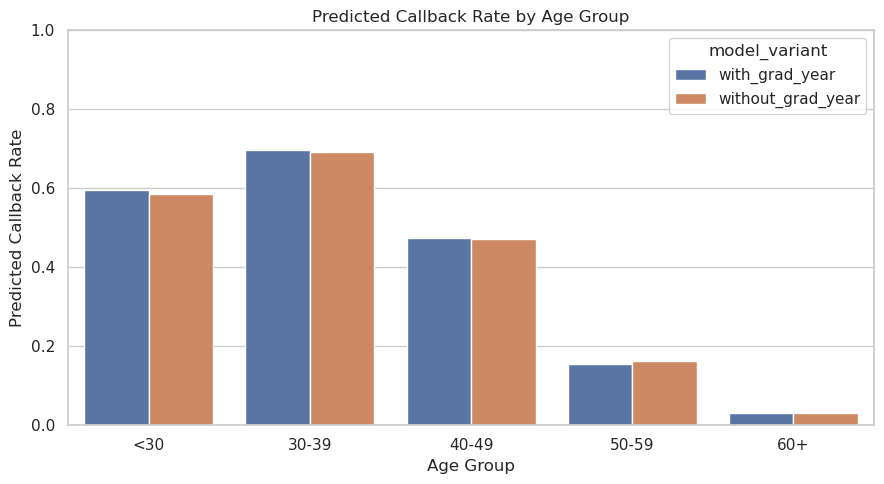

In [32]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=group_outcomes,
    x="age_group",
    y="predicted_callback_rate",
    hue="model_variant"
)
plt.title("Predicted Callback Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Predicted Callback Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

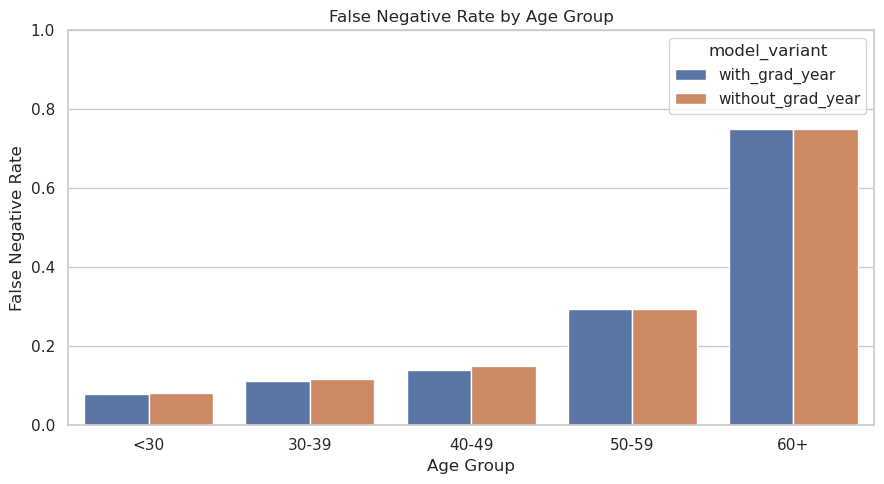

In [33]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=group_error_metrics,
    x="age_group",
    y="fnr",
    hue="model_variant"
)
plt.title("False Negative Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

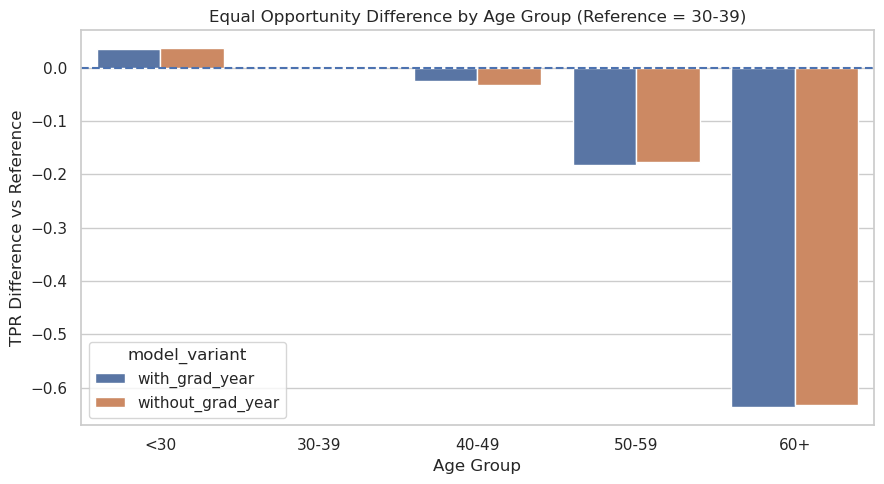

In [34]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=fairness_comparison,
    x="age_group",
    y="equal_opportunity_difference",
    hue="model_variant"
)
plt.axhline(0, linestyle="--")
plt.title(f"Equal Opportunity Difference by Age Group (Reference = {REFERENCE_GROUP})")
plt.xlabel("Age Group")
plt.ylabel("TPR Difference vs Reference")
plt.tight_layout()
plt.show()

## Interpret Results (Proxy Leakage Analysis)

This ablation compares two otherwise identical models that differ only in whether `graduation_year` is included.

Removing `graduation_year` has minimal impact on both model performance and fairness metrics.

Overall performance remains effectively unchanged, indicating that the model does not rely heavily on graduation year as a predictive feature.

More importantly, group-level disparities persist across all age groups. In particular, the oldest group (60+) continues to exhibit substantially lower predicted callback rates and significantly worse true positive rates, with only negligible changes after the ablation.

These results suggest that age-related information is encoded redundantly across multiple resume features. As a result, removing a single proxy variable is insufficient to eliminate disparities.

This demonstrates that proxy bias in machine learning systems is not attributable to any single feature, but rather emerges from the combined structure of correlated variables.

## Save Ablation Outputs

In [38]:
reports_tables_dir = PROJECT_ROOT / "reports" / "tables"
reports_figures_dir = PROJECT_ROOT / "reports" / "figures"
models_dir = PROJECT_ROOT / "models"

reports_tables_dir.mkdir(parents=True, exist_ok=True)
reports_figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

In [39]:
overall_comparison.to_csv(reports_tables_dir / "ablation_overall_comparison.csv", index=False)
group_outcomes.to_csv(reports_tables_dir / "ablation_group_outcomes.csv", index=False)
group_error_metrics.to_csv(reports_tables_dir / "ablation_group_error_metrics.csv", index=False)
fairness_comparison.to_csv(reports_tables_dir / "ablation_fairness_comparison.csv", index=False)

In [40]:
joblib.dump(model_with, models_dir / "logreg_with_grad_year.joblib")
joblib.dump(model_without, models_dir / "logreg_without_grad_year.joblib")

['/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/models/logreg_without_grad_year.joblib']